In [59]:
!pip install openai==1.65.2


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# Add Azure OpenAI package
from openai import AzureOpenAI
import requests
import base64

1.Deploy a FLUX-1.1-pro model <br>
2.Collect the ***endpoint***, ***Key*** and ***deployment name*** of the model from the trainer and paste the same in the below place holders


In [61]:
# Set the API keys, endpoint and model deployment
azure_oai_endpoint = "https://m-trainer5-6473-resource.cognitiveservices.azure.com/"
azure_oai_key = "mByZ6eaztqWhvChE5EOVFDs11DQcoO1O9HdDiyTHB07Q3BGtfqO1JQQJ99CFACHYHv6XJ3w3AAAAACOG8mGy"
azure_oai_deployment = "FLUX.2-pro"

In [62]:
# Initialize request settings
azure_endpoint = azure_oai_endpoint
api_key = azure_oai_key
api_version = "preview"

In [63]:
# Get prompt for image to be generated
prompt = input("\nEnter a prompt to request an image: ")

In [64]:
# Build request URL/body based on FLUX model family
deployment_name = azure_oai_deployment.strip()
base_endpoint = azure_endpoint.rstrip("/")

if deployment_name.lower().startswith("flux.2"):
    # FLUX.2 models use the BFL provider API route.
    model_path = "flux-2-pro" if "pro" in deployment_name.lower() else "flux-2-flex"
    url = f"{base_endpoint}/providers/blackforestlabs/v1/{model_path}?api-version={api_version}"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    body = {
        "model": deployment_name,
        "prompt": prompt,
        "width": 1024,
        "height": 1024,
        "output_format": "png",
        "num_images": 1
    }
else:
    # FLUX-1.1-pro and FLUX.1-Kontext-pro can use the Image API route.
    url = f"{base_endpoint}/openai/v1/images/generations?api-version={api_version}"
    headers = {"api-key": api_key, "Content-Type": "application/json"}
    body = {
        "model": deployment_name,
        "prompt": prompt,
        "n": 1,
        "size": "1024x1024"
    }

print("Request URL:", url)
print("Deployment:", deployment_name)

Request URL: https://m-trainer5-6473-resource.cognitiveservices.azure.com/providers/blackforestlabs/v1/flux-2-pro?api-version=preview
Deployment: FLUX.2-pro


In [65]:
import json

response = requests.post(url, headers=headers, json=body)
content_type = response.headers.get("content-type", "")
print("Status:", response.status_code)
print("Content-Type:", content_type if content_type else "<missing>")

response_text = response.text.strip()
if not response_text:
    raise RuntimeError("Empty response body from server. Check endpoint, deployment, API version, and key.")

result = None
if "application/json" in content_type.lower():
    try:
        result = response.json()
    except ValueError:
        # Some responses contain multiple JSON lines. Parse the first JSON object.
        first_line = response_text.splitlines()[0]
        try:
            result = json.loads(first_line)
        except Exception:
            print("Raw response (first 1000 chars):")
            print(response_text[:1000])
            raise RuntimeError("Failed to parse JSON response.")
else:
    print("Raw response (first 1000 chars):")
    print(response_text[:1000])
    raise RuntimeError("Server returned non-JSON response.")

if response.status_code >= 400:
    print("API error payload:")
    print(result)
    raise RuntimeError(f"Image generation request failed with HTTP {response.status_code}.")

print("API response keys:", list(result.keys()))

Status: 200
Content-Type: application/json
API response keys: ['created', 'data', 'request_meta']


In [66]:
# Extract image payload (handles both base64 and URL responses)
image_base64 = None
image_url = None

if isinstance(result, dict):
    data = result.get("data")
    if isinstance(data, list) and len(data) > 0 and isinstance(data[0], dict):
        image_base64 = data[0].get("b64_json")
        image_url = data[0].get("url")

    if image_base64 is None:
        image_base64 = result.get("b64_json") or result.get("image")

if image_base64 is None and image_url is None:
    raise RuntimeError(f"Could not find image data in response. Keys: {list(result.keys())}")

print("Image source:", "base64" if image_base64 else "url")

Image source: base64


In [70]:
# Save image from base64 payload or downloadable URL
import os

save_path = "generated_image.png"
abs_path = os.path.abspath(save_path)

if image_base64:
    image_bytes = base64.b64decode(image_base64)
    with open(save_path, "wb") as f:
        f.write(image_bytes)
elif image_url:
    img_response = requests.get(image_url, timeout=60)
    img_response.raise_for_status()
    with open(save_path, "wb") as f:
        f.write(img_response.content)
else:
    raise RuntimeError("No image payload available to save.")

print(f"Image successfully saved as: {abs_path}")

Image successfully saved as: c:\Users\crbha\Downloads\generated_image.png


Prompt: a man working in sea with his wife


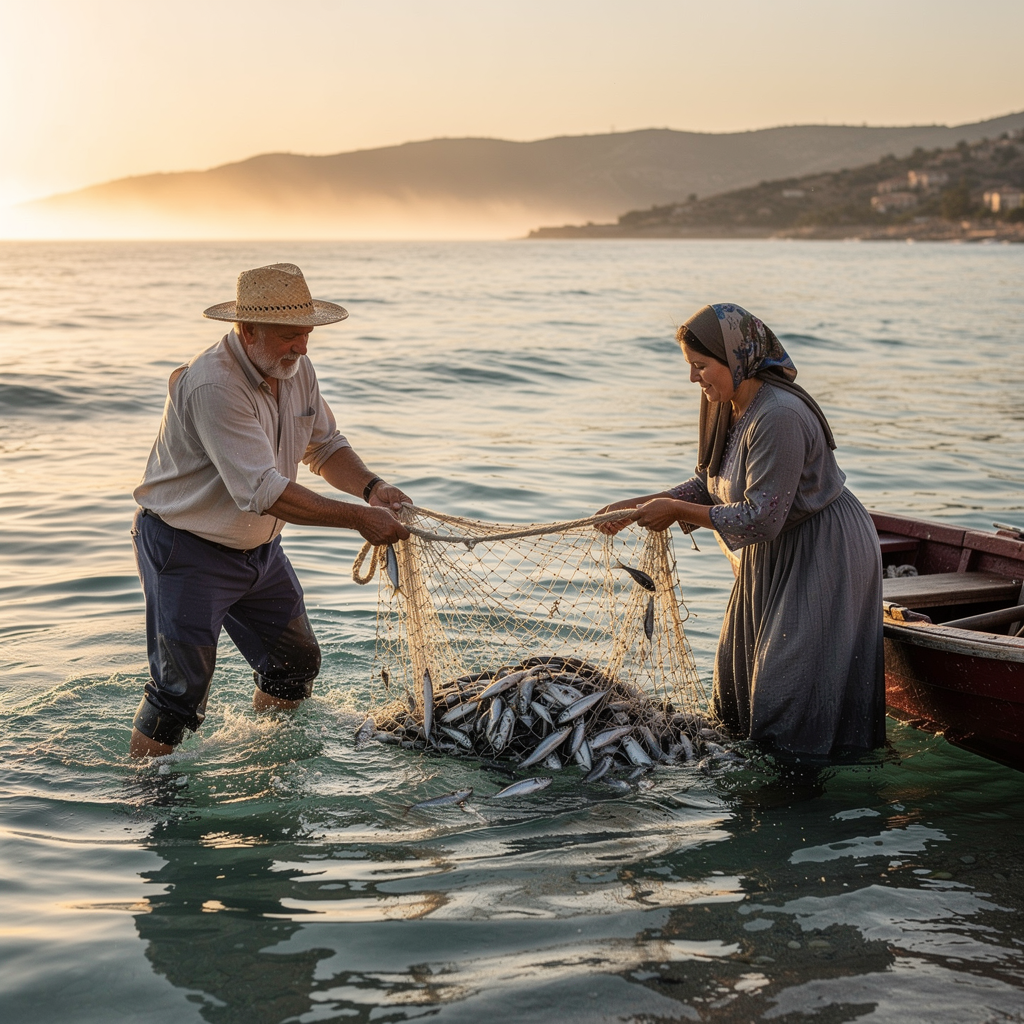

In [72]:
# Display prompt and saved image in a separate cell
from IPython.display import display, Image

print(f"Prompt: {prompt}")
display(Image(filename=save_path))